In [2]:
import numpy as np
import pandas as pd
from plotly.express import pie

import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

import plotly.io as pio
pio.renderers.default = "iframe"

In [3]:
data = pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [4]:
data.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [5]:
data[data["isFlaggedFraud"] == 1].head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.0,0.0,1,1
5996407,425,TRANSFER,10000000.00,C689608084,19585040.37,19585040.37,C1392803603,0.0,0.0,1,1
5996409,425,TRANSFER,9585040.37,C452586515,19585040.37,19585040.37,C1109166882,0.0,0.0,1,1
6168499,554,TRANSFER,3576297.10,C193696150,3576297.10,3576297.10,C484597480,0.0,0.0,1,1
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1
6281482,646,TRANSFER,10000000.00,C19004745,10399045.08,10399045.08,C1806199534,0.0,0.0,1,1


In [6]:
data[data["isFraud"] == 1].head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.0,0.00,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.00,1,0
681,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.0,12145.85,1,0
724,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,1,0
970,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,0
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.00,1,0


In [7]:
rows, columns = data.shape

In [8]:
rows

6362620

In [9]:
counts = data["isFraud"].value_counts().reset_index()

print(counts["count"].tolist())

#counts.loc[1, "count"] *= 1000

#print(counts["count"].tolist())

fig = pie(counts, names="isFraud", values="count", title='Testing pie plots')

fig.update_traces(
    pull=[0, 0.2], textinfo="percent+label", hoverinfo="label+value+percent"
)

fig.show()

[6354407, 8213]


In [10]:
#train_data, test_data = train_test_split(data, test_size=0.2)

In [12]:
from enum import Enum

#print(train_data.shape)
#print(test_data.shape)

class TypeEnum(Enum):
    CASH_OUT = 1
    CASH_IN = 2
    PAYMENT = 3
    TRANSFER = 4
    DEBIT = 5

enum_mapping = {item.name: item.value for item in TypeEnum}

def process_columns(data_frame_orig):
    data_frame = data_frame_orig.copy()

    data_frame.pop("isFlaggedFraud")
    data_frame.pop("nameOrig")
    data_frame.pop("nameDest")
    
    type_orig = data_frame.pop("type")
    
    data_frame["transactionType"] = type_orig.map(enum_mapping)

    y = data_frame.pop("isFraud")
    X = data_frame

    return X, y

df = data.copy()

#X, y = process_columns(train_data)
#X_test, y_test = process_columns(test_data)

X_full, y_full = process_columns(data)

In [13]:
X, X_test, y, y_test = train_test_split(X_full, y_full, test_size=0.2)

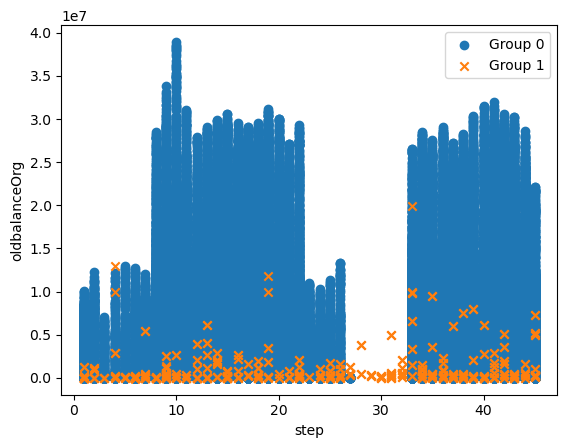

In [14]:
#x1 = data["amount"]
#x2 = data["oldbalanceOrg"]

#print(x1)
#print(x2)

marker_map = {
    0: 'o',
    1: 'x'
}

df = df.head(1000000)

columns = ["step", "oldbalanceOrg"]

for isFraud in range(2):
    #x1_val = [x[i] for i in range(len(x1)) if categories[i] == isFraud]
    #x2_val = [y[i] for i in range(len(x2)) if categories[i] == isFraud]

    x1_val = df.loc[df["isFraud"] == isFraud, columns[0]]
    x2_val = df.loc[df["isFraud"] == isFraud, columns[1]]

    corplot = plt.scatter(x1_val, x2_val, marker=marker_map[isFraud], label=f'Group {isFraud}')

plt.xlabel(columns[0])
plt.ylabel(columns[1])
plt.legend(loc="upper right")
plt.show()

In [15]:
##### observations #####

# nameOrig, nameDest don't show anything useful, as they are unique

# fraud is spread across many values of step, but for some step values there are little legit transactions

# step can be used as one of the axes for scatter plots

# the type for fraudulent transaction is either CASH_OUT or TRANSFER, so this should be one of the features

# amount and oldbalanceDest are usually at lower bound, but they can also be legit transactions

# usually fraudulent transaction takes all the account money, so newbalanceOrig is zero often

In [16]:
X_full.shape

(6362620, 7)

In [17]:
X.shape

(5090096, 7)

In [18]:
y.shape

(5090096,)

In [19]:
# show all rows
pd.set_option('display.max_rows', None)

X.head(100)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,transactionType
1034446,93,12047.01,52117.00,40069.99,0.00,0.00,3
2089550,182,10180.31,1073.00,11253.31,507178.84,496998.53,2
2317081,188,1769.67,0.00,0.00,0.00,0.00,3
5138979,356,80063.21,724.00,80787.21,123346.83,43283.62,2
2899556,228,10167.86,7028.00,0.00,0.00,0.00,3
3075762,235,171415.45,5826140.89,5997556.33,408050.14,236634.70,2
4315230,308,1678239.45,0.00,0.00,6025677.63,7703917.08,4
5637107,396,149894.88,30648.00,180542.88,258303.88,108409.00,2
1827520,163,196664.86,2969305.31,3165970.16,216922.18,20257.33,2
6290394,661,9506.00,0.00,0.00,0.00,0.00,3


In [20]:
model = DecisionTreeClassifier(class_weight="balanced")

In [21]:
model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [22]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances)

step               0.040205
amount             0.154898
oldbalanceOrg      0.352085
newbalanceOrig     0.376082
oldbalanceDest     0.002123
newbalanceDest     0.051241
transactionType    0.023366
dtype: float64


In [23]:
train_accuracy = model.score(X, y)
test_accuracy = model.score(X_test, y_test)

print(train_accuracy)
print(test_accuracy)

train_accuracy_positive = model.score(X[y == 1], y[y == 1])
test_accuracy_positive = model.score(X_test[y_test == 1], y_test[y_test == 1])

print(train_accuracy_positive)
print(test_accuracy_positive)

1.0
0.9996699472858666
1.0
0.8443768996960487


In [24]:
predict_set = X_test.head(n=100)

print("predict set:\n\n", predict_set)

print("\ny_test:\n\n", y_test.head(n=100))

y_predicted = model.predict(predict_set)

print("\ny_predicted:\n\n", y_predicted)

predict set:

          step      amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
5722311   398    12246.01           0.00            0.00            0.00   
4368624   310  4008740.83           0.00            0.00     10281960.58   
736963     38   100791.98           0.00            0.00       241731.00   
126714     11    26543.00       11133.00            0.00            0.00   
4859894   348   193873.21       39682.00            0.00       807630.18   
1541072   154   397070.01           0.00            0.00      2444754.11   
2874192   227   312928.01     1796162.16      2109090.17       538771.55   
5289336   373  1024201.82         549.07            0.00      3006527.72   
2542498   206     4041.37       98476.00        94434.63            0.00   
776075     39   343826.62     4418820.81      4762647.43      1006739.98   
43473       9    26618.48           0.00            0.00            0.00   
3735823   278   321430.08       11539.00            0.00       495636.06 

In [25]:
(y == 1).sum() / (y == 0).sum()

0.001292016095908196

In [26]:
(y_test == 1).sum() / (y_test == 0).sum()

0.0012943797167157534

In [27]:
X_test_positive = X_test[y_test == 1]
y_positive_predicted = model.predict(X_test_positive)

with np.printoptions(threshold=np.inf):
    print(y_positive_predicted)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1
 1 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0
 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1
 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 1 0 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1
 0 1 1 0 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1
 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0
 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 

In [28]:
import joblib

In [29]:
joblib.dump(model, "1_fraud_detection.joblib")

['1_fraud_detection.joblib']

In [30]:
model = joblib.load("1_fraud_detection.joblib")

In [31]:
from sklearn.tree import export_graphviz

In [32]:
export_graphviz(model, out_file="1_fraud_detection.dot")